# Batch Docking: Candidate Compounds vs TBXT Pocket A

Dock all candidate compounds from the CWML virtual screen export against
the TBXT-A pocket, rank by docking score, then run full interaction
analysis and 3D visualization for the top 3.

In [1]:
import pandas as pd
from tbxt_hackathon.docking import dock_batch, dock_single

## 1. Load candidates

In [3]:
POCKET_PDB = "../data/structures/TGT_TBXT_A_pocket.pdb"

candidates = pd.read_csv(
    "../data/candidates-TBXT-cwml.csv"
)
assert candidates.shape[0] > 0, "No candidates loaded"
smiles_list = candidates["Molecule"].tolist()
ids = candidates["Id"].tolist()
print(f"Loaded {len(smiles_list)} candidates")

Loaded 20 candidates


## 2. Batch docking (fast scoring)

2 conformers per compound, exhaustiveness=2, 1 pose each for speed.

In [4]:
batch_scores = dock_batch(
    smiles_list,
    POCKET_PDB,
    n_conformers=2,
    exhaustiveness=2,
    n_poses=1,
)
assert batch_scores.shape[0] == len(smiles_list)

batch_scores.insert(1, "id", ids)
batch_scores = batch_scores.sort_values("score").reset_index(drop=True)
print(f"Successfully docked: {(batch_scores['status'] == 'ok').sum()} / {len(batch_scores)}")
batch_scores.head(10).style.background_gradient(subset=["score"], cmap="RdYlGn_r")

Successfully docked: 20 / 20


,smiles,id,score,ligand_efficiency,n_heavy_atoms,mw,score_std,status
0,O=C(c1ccc2c(c1)CCCO2)N1CCC2(CC1)CC(=O)N(c1ccccc1)C2=O,SM-AFB2BKPV,-6.074000,0.202500,30,404.470000,0.004000,ok
1,O=C(Cc1ccccc1)Nc1cccc(NC(=O)NCc2ccc3ncsc3c2)c1,SM-ZBGNCUEF,-5.863000,0.195400,30,416.510000,0.021000,ok
2,c1ccc(Oc2nc(Oc3ccccc3)nc(Oc3ccccc3)n2)cc1,SM-JX8YSEGA,-5.599000,0.207400,27,357.370000,0.001000,ok
3,O=C(Nc1cccc(N2CCOCC2=O)c1)N1CCC2(CC1)Cc1ccccc1O2,SM-QWRJV6JJ,-5.553000,0.185100,30,407.470000,0.070000,ok
4,CN(c1ccccc1)c1ccc(CNC(=O)c2cccc3ccn(C)c23)cn1,SM-B27WJ7B3,-5.519000,0.197100,28,370.460000,0.042000,ok
5,Cc1ccc(-c2cscn2)cc1NC(=O)N1CCN(c2ncc(F)cn2)CC1,SM-1K1DPFWB,-5.462000,0.195100,28,398.470000,0.292000,ok
6,O=C(NCc1ccccc1)N1CCN(C(=O)c2ccc(Cn3cc(Br)cn3)o2)CC1,SM-UN33CVSD,-5.451000,0.181700,30,472.340000,0.005000,ok
7,CCCOc1ccccc1CNC(=O)Nc1ccc(F)c(NC(C)=O)c1F,SM-LSWKXD8P,-5.404000,0.200100,27,377.390000,0.017000,ok
8,O=C(Nc1ccccc1)c1ccc(F)c(-c2cnc(N3CCC(CO)CC3)nc2)c1,SM-DZQADUHH,-5.354000,0.178500,30,406.460000,0.150000,ok
9,COc1ccccc1NC(=O)C1CCN(C(=O)c2cc(C)c3c(cnn3C)c2)CC1,SM-AMF93CLJ,-5.269000,0.175600,30,406.490000,0.023000,ok


## 3. Score distribution

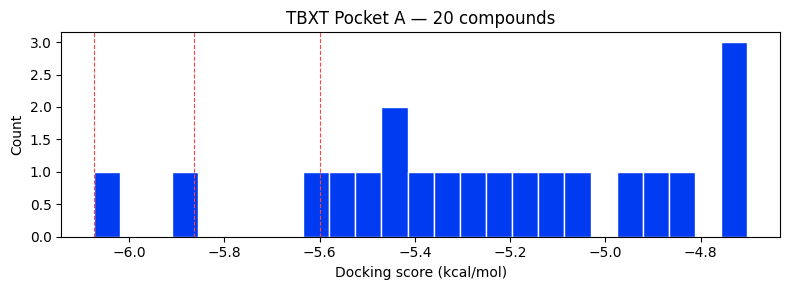

In [5]:
import matplotlib.pyplot as plt

ok = batch_scores[batch_scores["status"] == "ok"]

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(ok["score"], bins=25, edgecolor="white", color="#013BF1")
ax.set_xlabel("Docking score (kcal/mol)")
ax.set_ylabel("Count")
ax.set_title(f"TBXT Pocket A — {len(ok)} compounds")

for i, row in ok.head(3).iterrows():
    ax.axvline(row["score"], color="#FF4444", ls="--", lw=0.8)

plt.tight_layout()
plt.show()

## 4. Full docking & 3D poses for top 3

Re-dock the top 3 with higher exhaustiveness and multiple poses for
detailed interaction analysis.

In [6]:
top3 = batch_scores[batch_scores["status"] == "ok"].head(3)

reports = []
for _, row in top3.iterrows():
    print(f"\nDocking {row['id']} ...")
    rpt = dock_single(
        row["smiles"],
        POCKET_PDB,
        n_conformers=3,
        exhaustiveness=32,
        n_poses=5,
    )
    reports.append((row["id"], rpt))
    print(rpt.summary())


Docking SM-AFB2BKPV ...
Docking report: O=C(c1ccc2c(c1)CCCO2)N1CCC2(CC1)CC(=O)N(c1ccccc1)C2=O
  Best score:        -6.07 kcal/mol  (conformer 0, pose 0)
  Inter-molecular:   -6.78 kcal/mol
  Intra-molecular:   -0.59 kcal/mol
  Ligand efficiency: 0.202 kcal/mol/HA
  Heavy atoms:       30
  MW:                404.5
  Conformers run:    3
  Total poses:       14
  Score range:       -6.07 to -4.99 kcal/mol

  Best-pose interactions (7):
    hydrophobic    LEU61    CD2   3.62 A
    hydrophobic    CYS92    CA    3.94 A
    hydrophobic    VAL93    CG2   3.50 A
    hydrophobic    ILE95    CD1   3.89 A
    hydrophobic    ARG139   CZ    3.87 A
    hydrophobic    HIS141   CG    3.76 A
    hydrophobic    ILE152   CG2   3.50 A

Docking SM-ZBGNCUEF ...
Docking report: O=C(Cc1ccccc1)Nc1cccc(NC(=O)NCc2ccc3ncsc3c2)c1
  Best score:        -5.86 kcal/mol  (conformer 1, pose 0)
  Inter-molecular:   -7.91 kcal/mol
  Intra-molecular:   -0.50 kcal/mol
  Ligand efficiency: 0.195 kcal/mol/HA
  Heavy atoms:  

### Rank 1

In [7]:
mol_id, rpt = reports[0]
print(f"{mol_id}: {rpt.score:.2f} kcal/mol  LE={rpt.ligand_efficiency:.3f}")
rpt.show_3d()

SM-AFB2BKPV: -6.07 kcal/mol  LE=0.202


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### Rank 2

In [8]:
mol_id, rpt = reports[1]
print(f"{mol_id}: {rpt.score:.2f} kcal/mol  LE={rpt.ligand_efficiency:.3f}")
rpt.show_3d()

SM-ZBGNCUEF: -5.86 kcal/mol  LE=0.195


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### Rank 3

In [9]:
mol_id, rpt = reports[2]
print(f"{mol_id}: {rpt.score:.2f} kcal/mol  LE={rpt.ligand_efficiency:.3f}")
rpt.show_3d()

SM-JX8YSEGA: -5.67 kcal/mol  LE=0.210


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## 5. Interaction comparison

In [10]:
rows = []
for mol_id, rpt in reports:
    bp = rpt.best_pose
    rows.append({
        "id": mol_id,
        "smiles": rpt.smiles,
        "score": rpt.score,
        "LE": rpt.ligand_efficiency,
        "HA": rpt.n_heavy_atoms,
        "inter": bp.inter_energy,
        "intra": bp.intra_energy,
        "hbonds": sum(1 for x in bp.interactions if x.type == "hbond"),
        "hydrophobic": sum(1 for x in bp.interactions if x.type == "hydrophobic"),
        "pi_stack": sum(1 for x in bp.interactions if x.type == "pi_stacking"),
        "salt_bridge": sum(1 for x in bp.interactions if x.type == "salt_bridge"),
        "total_interactions": len(bp.interactions),
        "key_residues": ", ".join(sorted({x.protein_residue for x in bp.interactions})),
    })

comparison = pd.DataFrame(rows)
comparison.style.background_gradient(subset=["score"], cmap="RdYlGn_r")

,id,smiles,score,LE,HA,inter,intra,hbonds,hydrophobic,pi_stack,salt_bridge,total_interactions,key_residues
0,SM-AFB2BKPV,O=C(c1ccc2c(c1)CCCO2)N1CCC2(CC1)CC(=O)N(c1ccccc1)C2=O,-6.071000,0.202367,30,-6.780000,-0.586000,0,7,0,0,7,"ARG139, CYS92, HIS141, ILE152, ILE95, LEU61, VAL93"
1,SM-ZBGNCUEF,O=C(Cc1ccccc1)Nc1cccc(NC(=O)NCc2ccc3ncsc3c2)c1,-5.857000,0.195233,30,-7.911000,-0.503000,0,6,0,0,6,"GLY126, HIS141, ILE152, ILE95, TYR94, VAL93"
2,SM-JX8YSEGA,c1ccc(Oc2nc(Oc3ccccc3)nc(Oc3ccccc3)n2)cc1,-5.665000,0.209815,27,-7.652000,-0.723000,0,7,1,0,8,"CYS92, HIS141, ILE152, ILE95, LEU61, VAL143, VAL93"


## 6. Save results

In [11]:
batch_scores.to_csv("../data/docking_scores_pocket_A.csv", index=False)
comparison.to_csv("../data/docking_top3_pocket_A.csv", index=False)
print("Saved to data/docking_scores_pocket_A.csv and data/docking_top3_pocket_A.csv")

Saved to data/docking_scores_pocket_A.csv and data/docking_top3_pocket_A.csv
